## County Health Ranking Dataset


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from functions import merge_migration_health_ranking_data
from functions import get_county_health_data

## Get the Health Dataset



In [2]:
health_df = get_county_health_data()
health_df.head()
#health_df.shape

,FIPS,State,County,Number of Counties Included in Health Groups,Health_Z_Score,Health Group,Health Group Range,Community_Z_Score,Health Group.1,Health Group Range.1
1,01001,Alabama,Autauga,67,-0.040894,5.0,-0.05 to 0.27,0.114428,5.0,-0.17 to 0.03
2,01003,Alabama,Baldwin,67,0.309818,4.0,-0.38 to -0.06,0.386812,3.0,-0.58 to -0.37
3,01005,Alabama,Barbour,67,-1.116797,8.0,0.96 to 1.38,-0.822974,9.0,0.73 to 1.09
4,01007,Alabama,Bibb,67,-0.665055,7.0,0.6 to 0.95,-0.594501,8.0,0.47 to 0.72
5,01009,Alabama,Blount,67,-0.356964,6.0,0.28 to 0.6,-0.147988,6.0,0.03 to 0.24


## County Health Distribution
To plot the distribution, we used tidy data transformation using pandas.melt and pivoted the dataframe from two columns to a single column for the values (Score) and a categorical column (Metric). We chose seaborn.displot over standard histogram because it allowed us to normalize the Health and Community Conditions distributions in a shared density visual rather than comparing raw counts.  

The Health z-score is a composite score is derived from 5 health outcomes and primarily weighted (50%) by the Premature Death outcome per county. The other 50% is comprised of Poor Physical Health Days (10%), Poor Mental health Days (10%), Low Birthweight (20%), and Poro or Fair Health (10%). The Health distribution is more spread out because half of the score relies on mortality rates which can fluctuate due to local crises (violence, environmental disasters, drug related deaths, etc.). The heavy left tail may represent counties where premature death is significantly higher than the national average.

The Community Conditions composite score is derived from 24 community condition outcomes with similar weighting contributions to the overall score, allowing extreme values to cancel each other out and compress the z-scores Income Inequality and High School Completion (weighted 8% each), and the lowest weighted factors such as Dentists (1%) and Primary Care Physicians (2%).

We may find no evidence of a relationship or weak correlation between migration and Community Conditions for most counties, and we may find slightly higher evidence of a relationship for Health since there is wider variance. The negative skew represents counties with extremely poor Health. 



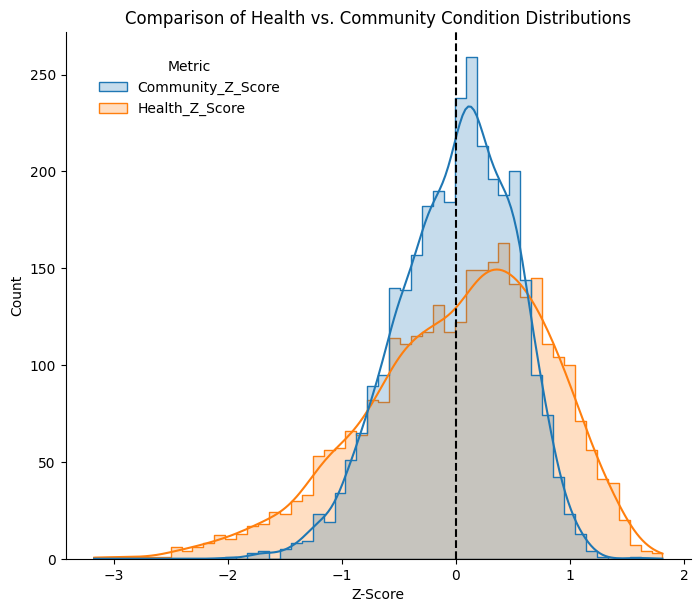

In [3]:
# Used tidy data transformation using pandas.melt and pivoted the dataframe from two columns to
# a single column for the values (Score) and a categorical column (Metric)
melted_health = health_df.melt(
    value_vars=['Community_Z_Score', 'Health_Z_Score'], 
    var_name='Metric', 
    value_name='Score'
)

# Used element=step over bars to see overlapping distributions
plot = sns.displot(
    data=melted_health, 
    x='Score', 
    hue='Metric',       
    kind='hist',       
    kde=True,          
    element='step',    
    height=6, 
    aspect=1.2
)

# Move the existing legend to the upper left
# bbox_to_anchor allows assigning the (x, y) position
sns.move_legend(plot, "upper left", bbox_to_anchor=(0.10, 0.95))

plt.title('Comparison of Health vs. Community Condition Distributions')
plt.xlabel('Z-Score')
plt.axvline(0, color='black', linestyle='--', label='National Average')
plt.show()

In [4]:
health_stats = health_df['Health_Z_Score'].describe()
print(f" health stats: {health_stats}")

 health stats: count    3089.000000
mean        0.015685
std         0.798560
min        -3.171721
25%        -0.498751
50%         0.121338
75%         0.603725
max         1.811810
Name: Health_Z_Score, dtype: float64


In [5]:
comm_stats = health_df['Community_Z_Score'].describe()
print(f" comm_stats: {comm_stats}")

 comm_stats: count    3089.000000
mean        0.003724
std         0.505255
min        -1.980535
25%        -0.333014
50%         0.050141
75%         0.384629
max         1.612949
Name: Community_Z_Score, dtype: float64


## Get County Migration Dataset


In [6]:
migration_df = pd.read_csv('data/county_to_county_US_2020.csv')
migration_df.head()
#migration_df.shape

,GEOID1,GEOID2,FULL1_NAME,FULL2_NAME,STATE1_NAME,STATE2_NAME,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,state,county
0,1001,1003,"Autauga County, Alabama","Baldwin County, Alabama",Alabama,Alabama,30.0,489.0,-459.0,54929.0,57775.0,1,1
1,1001,1005,"Autauga County, Alabama","Barbour County, Alabama",Alabama,Alabama,5.0,0.0,5.0,54929.0,57775.0,1,1
2,1001,1007,"Autauga County, Alabama","Bibb County, Alabama",Alabama,Alabama,12.0,48.0,-36.0,54929.0,57775.0,1,1
3,1001,1015,"Autauga County, Alabama","Calhoun County, Alabama",Alabama,Alabama,2.0,23.0,-21.0,54929.0,57775.0,1,1
4,1001,1017,"Autauga County, Alabama","Chambers County, Alabama",Alabama,Alabama,0.0,7.0,-7.0,54929.0,57775.0,1,1


## Get County Level Merge

In [7]:
final_county_df = merge_migration_health_ranking_data()
final_county_df.shape
final_county_df.head()

,GEOID1,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,STATE1_NAME,FULL1_NAME,Net_Migration_Rate,In_Migration_Rate,...,FIPS,State,County,Number of Counties Included in Health Groups,Health_Z_Score,Health Group,Health Group Range,Community_Z_Score,Health Group.1,Health Group Range.1
0,01001,3375.0,6501.0,-3126.0,54929.0,57775.0,Alabama,"Autauga County, Alabama",-56.909829,61.442954,...,01001,Alabama,Autauga,67,-0.040894,5.0,-0.05 to 0.27,0.114428,5.0,-0.17 to 0.03
1,01003,10770.0,8779.0,1991.0,216518.0,213875.0,Alabama,"Baldwin County, Alabama",9.195540,49.741823,...,01003,Alabama,Baldwin,67,0.309818,4.0,-0.38 to -0.06,0.386812,3.0,-0.58 to -0.37
2,01005,1522.0,1481.0,41.0,24792.0,24683.0,Alabama,"Barbour County, Alabama",1.653759,61.390771,...,01005,Alabama,Barbour,67,-1.116797,8.0,0.96 to 1.38,-0.822974,9.0,0.73 to 1.09
3,01007,1525.0,1372.0,153.0,22073.0,21903.0,Alabama,"Bibb County, Alabama",6.931545,69.088932,...,01007,Alabama,Bibb,67,-0.665055,7.0,0.6 to 0.95,-0.594501,8.0,0.47 to 0.72
4,01009,1914.0,2595.0,-681.0,57164.0,57718.0,Alabama,"Blount County, Alabama",-11.913092,33.482611,...,01009,Alabama,Blount,67,-0.356964,6.0,0.28 to 0.6,-0.147988,6.0,0.03 to 0.24


In [8]:
# Rename some columns to my own prefernces
final_county_df = final_county_df.rename(columns= {
    'STATE1_NAME': 'Origin_State',
    'STATE2_NAME': 'Dest_State',
    'FULL1_NAME': 'Origin_County_Name',
    'FULL2_NAME': 'Dest_County_Name',
    'GEOID1' : 'Origin_FIPS_Code',  
    'GEOID2' : 'Dest_FIPS_Code',
    'MOVEDNET': 'Total_Net_Migration',
    'POP1YR': 'Population'
})

In [9]:
final_county_df.head()

,Origin_FIPS_Code,MOVEDIN,MOVEDOUT,Total_Net_Migration,Population,POP1YRAGO,Origin_State,Origin_County_Name,Net_Migration_Rate,In_Migration_Rate,...,FIPS,State,County,Number of Counties Included in Health Groups,Health_Z_Score,Health Group,Health Group Range,Community_Z_Score,Health Group.1,Health Group Range.1
0,01001,3375.0,6501.0,-3126.0,54929.0,57775.0,Alabama,"Autauga County, Alabama",-56.909829,61.442954,...,01001,Alabama,Autauga,67,-0.040894,5.0,-0.05 to 0.27,0.114428,5.0,-0.17 to 0.03
1,01003,10770.0,8779.0,1991.0,216518.0,213875.0,Alabama,"Baldwin County, Alabama",9.195540,49.741823,...,01003,Alabama,Baldwin,67,0.309818,4.0,-0.38 to -0.06,0.386812,3.0,-0.58 to -0.37
2,01005,1522.0,1481.0,41.0,24792.0,24683.0,Alabama,"Barbour County, Alabama",1.653759,61.390771,...,01005,Alabama,Barbour,67,-1.116797,8.0,0.96 to 1.38,-0.822974,9.0,0.73 to 1.09
3,01007,1525.0,1372.0,153.0,22073.0,21903.0,Alabama,"Bibb County, Alabama",6.931545,69.088932,...,01007,Alabama,Bibb,67,-0.665055,7.0,0.6 to 0.95,-0.594501,8.0,0.47 to 0.72
4,01009,1914.0,2595.0,-681.0,57164.0,57718.0,Alabama,"Blount County, Alabama",-11.913092,33.482611,...,01009,Alabama,Blount,67,-0.356964,6.0,0.28 to 0.6,-0.147988,6.0,0.03 to 0.24


## Net Migration Rate Distribution

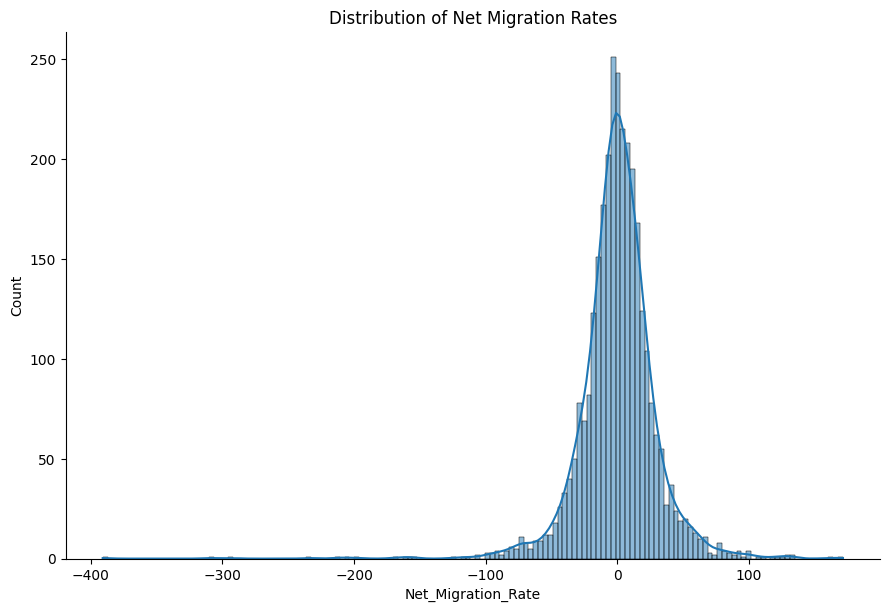

In [10]:
g = sns.displot(final_county_df, x='Net_Migration_Rate', kde=True, height=6, aspect=1.5)
g.set(title='Distribution of Net Migration Rates')
plt.show() 

In [11]:
migration_stats = final_county_df['Net_Migration_Rate'].describe()
print(migration_stats)

count    3080.000000
mean        0.202129
std        30.272184
min      -391.031390
25%       -12.589727
50%         0.421767
75%        14.225019
max       171.486318
Name: Net_Migration_Rate, dtype: float64


## State Level Merge
To see state level trends we aggregated our county data to the state level. The challenge here is that we can’t take the mean of the county z-scores because low population areas like Alpine County would have the same influence on California’s score as Los Angeles. We weighted both the Health_Z_Score and Community_Z_Score by the county's Population to ensure the state level metrics reflect the experience of the average resident. 

We then split the county dataset into state groups using groupby, applied the weighted aggregation to each State group and recalculated the Net Migration Rate per 1000 people for each state. This tells us whether a state gains or loses X net migrants per every 1000 residents.

State Net Migration Rate = (Total State Net Migration / Total State Population) * 1000


In [12]:
def get_state_data(merged_county_df):

    # Using a weighted average for z-scores since counties have different populations
    def weighted_aggregation(x):

        # x is the group of all counties in a state
        # Calculate weighted average for Health z-score
        w_health = np.average(x['Health_Z_Score'], weights=x['Population'])
        
        # Calculate weighted average for Community Z-score
        w_comm = np.average(x['Community_Z_Score'], weights=x['Population'])
        
        total_net_mig = x['Total_Net_Migration'].sum()
        total_pop = x['Population'].sum()
        
        return pd.Series({
            'Health_Z_Score': w_health,
            'Community_Z_Score': w_comm,
            'Total_Net_Migration': total_net_mig,
            'Population': total_pop
        })

    # Group by state and apply aggregation
    state_df = merged_county_df.groupby('State').apply(weighted_aggregation, include_groups=False).reset_index()
    
    return state_df

state_df = get_state_data(final_county_df)

# Add migration rate (net migration / pop), we gain x net migrants per every 1000 residents
state_df['Net_Migration_Rate'] = (state_df['Total_Net_Migration'] / state_df["Population"]) * 1000

#state_df.head()
state_df.shape

(50, 6)

### Insight 1- Q1: How do the aggregated health and community scores correlate to intra-US migration patterns? 
Used Net Migration Rate per 1000 people because migration counts would result in seeing the largest counties. 

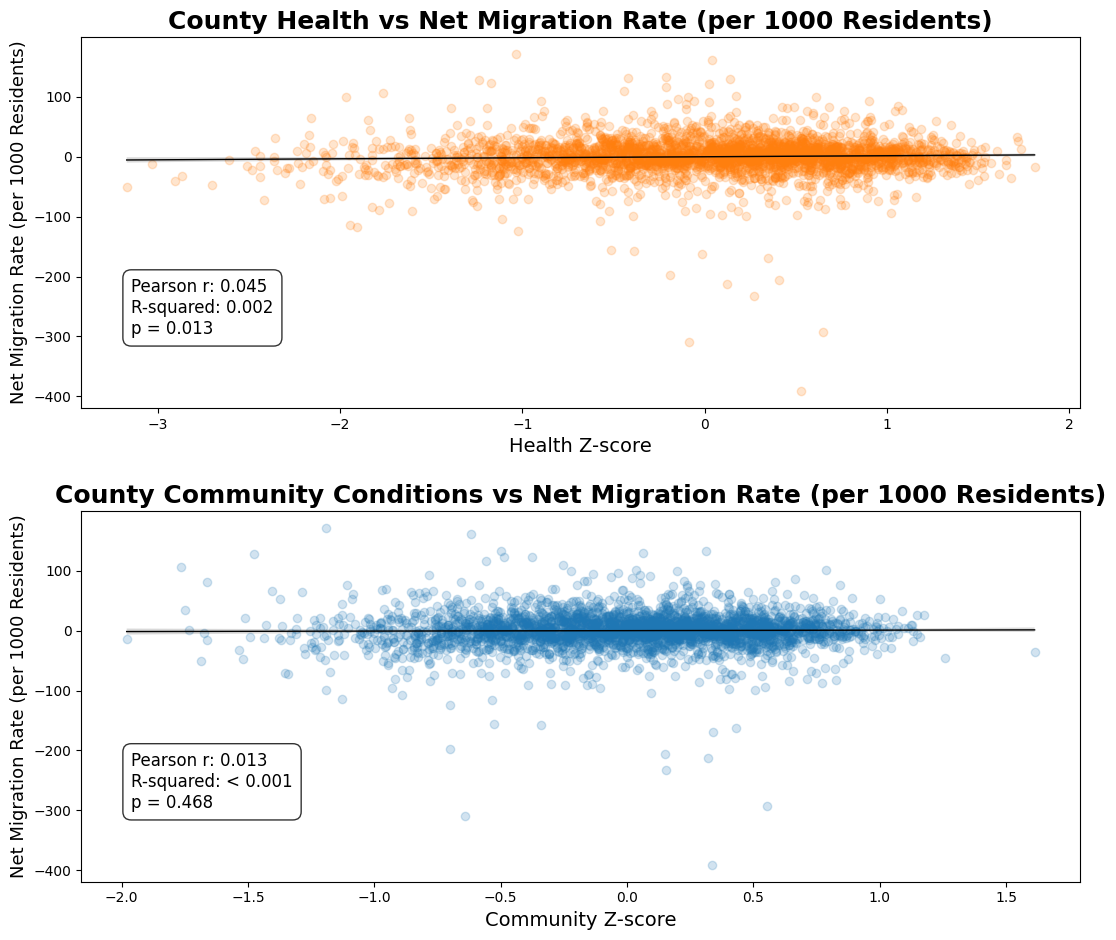

In [13]:
def correlations_viz(final_county_df, state_df):
    fig, axes = plt.subplots(2, 1, figsize=(11, 9.5))

    colors = sns.color_palette()
    health_color = colors[1]
    comm_color = colors[0]
    
    def plot_corr(df, x_col, y_col, ax, color, title, xlabel_text):
        
        valid_data = df[[x_col, y_col]].dropna()
        r, p = stats.pearsonr(valid_data[x_col], valid_data[y_col])
        r_sq = r**2
        
        sns.regplot(x=x_col, y=y_col, data=df, ax=ax, color=color,
                    scatter_kws={'alpha':0.2}, line_kws={'color':'black', 'linewidth':1})


        # R-quared shows on plot as 0.000, which statistically should say "<0.001", Check R-squared size
        if r_sq < 0.001:
            r_sq_str = "< 0.001"
        else:
            r_sq_str = f"{r_sq:.3f}"

        # Check P-value size
        if p < 0.001:
            p_str = "p < 0.001"
        else:
            p_str = f"p = {p:.3f}"

        stats_text = (f'Pearson r: {r:.3f}\nR-squared: {r_sq_str}\n{p_str}')
        
        ax.annotate(stats_text, xy=(0.05, 0.20), xycoords='axes fraction', 
                    fontsize=12, fontweight='normal', 
                    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8))
        
        ax.set_title(title, fontsize=18, fontweight='bold')
        ax.set_ylabel('Net Migration Rate (per 1000 Residents)', fontsize=13)
        ax.set_xlabel(xlabel_text, fontsize=14) 

    plot_corr(final_county_df, 'Health_Z_Score', 'Net_Migration_Rate', 
              axes[0], health_color, 'County Health vs Net Migration Rate (per 1000 Residents)',
              'Health Z-score')

    plot_corr(final_county_df, 'Community_Z_Score', 'Net_Migration_Rate', 
              axes[1], comm_color, 'County Community Conditions vs Net Migration Rate (per 1000 Residents)',
              'Community Z-score')

    plt.tight_layout(h_pad=2)
    plt.show() 

correlations_viz(final_county_df, state_df)

As the above plots shows, there is no statistically significant evidence of an association between Community Condition Z-scores and net migration at the county level (p = 0.468), and these results were also observed when aggregating the data at the state level for both Health and Community Condition Z-scores.

However, we did find statistically significant evidence (p < 0.05) that migration is positively associated with Health Z-scores at the county level, but the effect size is extremely small (Pearson r = 0.045). This tells us that while a linear relationship exists it is very weak. The Pearson r of 0.045 is equivalent to an R-squared of 0.002 which means 0.2% of the variance in migration is described by the linear regression on health.

We also tested for monotonicity with Spearman. The results showed a Spearman r close to 0 for both Health and Community Condition Z-scores at both the county and state levels. In addition, the p-values in Spearman are all greater than 0.05, meaning there is no statistical evidence of any relationship. 


## Is there a relationship between net migration and the healthiest and unhealthiest places?
We then tried a categorical approach to see if there would be a relationship between Net Migration and Health/Community Condition Z-scores.

In the below Mean Bar Plot I break the Health and Community Condition Z-Scores into 10 equal groups (Deciles) and plot the average migration rate for each group (Deciles: D1 = Lowest 10%, D10 = Highest 10%) based on their Health and Community Condition Z-scores using pd.qcut to see if migration behavior changes as specific thresholds. We used sns.barplot with errorbar='ci' for our visualization and added Z-score tiers on the x-axis, net migration rate per 1000 residents on the y-axis, and 95% confidence intervals to allow us to see the stability of the averages. This visualization shows that the relationship between Health/Community Z-scores and Net Migration is non-montonic, which is why we found low linear and rank correlations in the previous model. Since we don’t see an association with Pearson or Spearman for this complex relationship, we decided to use a one way analysis of variance (ANOVA) ols model confirm that the differences in migration rates between the groups were stastitically signficant and not random noise.

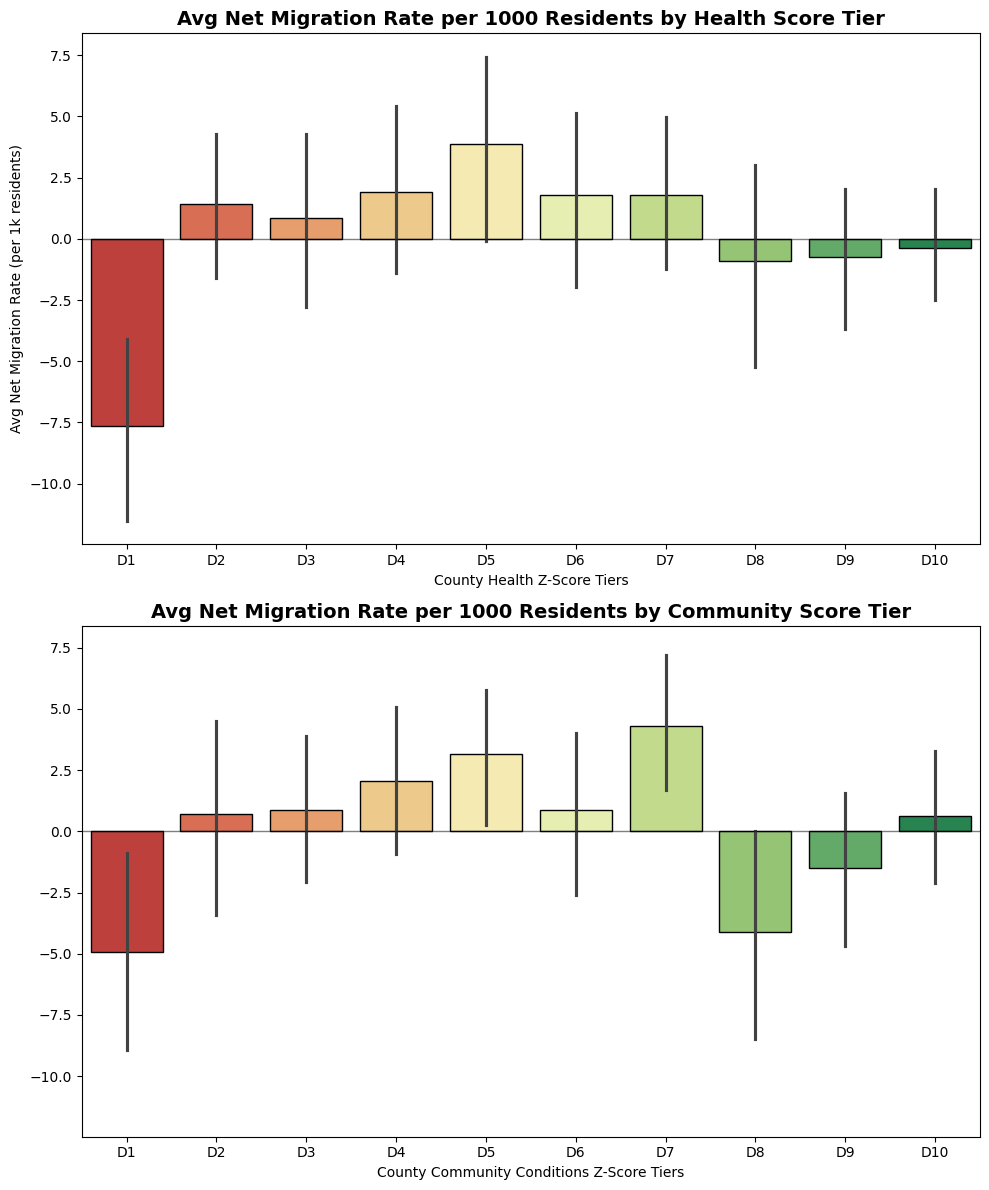

In [14]:
bin_df = final_county_df.copy()

# Separate z-score into deciles
labels = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10']

bin_df['Health_Decile'] = pd.qcut(bin_df['Health_Z_Score'], q=10, labels=labels)
bin_df['Community_Decile'] = pd.qcut(bin_df['Community_Z_Score'], q=10, labels=labels)

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=True)

#Health deciles vs migration
sns.barplot(
    data=bin_df, 
    x='Health_Decile', 
    y='Net_Migration_Rate', 
    hue='Health_Decile',    
    legend=False,          
    ax=axes[0],
    palette='RdYlGn', 
    edgecolor='black',
    errorbar=('ci', 95)
)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[0].set_title('Avg Net Migration Rate per 1000 Residents by Health Score Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('County Health Z-Score Tiers')
axes[0].set_ylabel('Avg Net Migration Rate (per 1k residents)')

# Community condition deciles vs migration
sns.barplot(
    data=bin_df, 
    x='Community_Decile', 
    y='Net_Migration_Rate', 
    hue='Community_Decile',  
    legend=False,            
    ax=axes[1],
    palette='RdYlGn',
    edgecolor='black',
    errorbar=('ci', 95)
)
axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1].set_title('Avg Net Migration Rate per 1000 Residents by Community Score Tier', fontsize=14, fontweight='bold')
axes[1].set_xlabel('County Community Conditions Z-Score Tiers')
axes[1].set_ylabel('') # Hide y-label for cleaner look

plt.tight_layout()
plt.show()

In [15]:
# One way ANOVA for Health Deciles to see if there's any difference between the groups
health_anova = ols('Net_Migration_Rate ~ C(Health_Decile)', data=bin_df).fit()
health_table = sm.stats.anova_lm(health_anova, typ=2)
print("\nHealth Decile ANOVA:")
print(health_table)


Health Decile ANOVA:
                        sum_sq      df         F    PR(>F)
C(Health_Decile)  2.684912e+04     9.0  3.277035  0.000558
Residual          2.794762e+06  3070.0       NaN       NaN


In [16]:
# One way ANOVA for Community Conditions Deciles
comm_anova = ols('Net_Migration_Rate ~ C(Community_Decile)', data=bin_df).fit()
comm_table = sm.stats.anova_lm(comm_anova, typ=2)
print("Community Condition ANOVA")
print(comm_table)

Community Condition ANOVA
                           sum_sq      df         F    PR(>F)
C(Community_Decile)  2.415826e+04     9.0  2.945769  0.001738
Residual             2.797453e+06  3070.0       NaN       NaN


The ANOVA test resulted in a p-value far below 0.05, so we reject the null hypothesis for both Health and Community Conditions. The Health F-statistic = 3.28 and Community F-statistic = 2.94, meaning the variation between the health tiers is 3.28 times stronger than the random variation within them. F > 1 means the signal is stronger than the noise. Therefore, the average net migration rates in the deciles are not equal. This means the variance between the Health and Community score tiers is significantly larger than the random variation within them, and this confirms that Health and Community Conditions have a relationship with Net Migration, but it's not linear or monotonic.

The Residual sum_sq=2.79 million means there is a large amount of unexplained variation in net migration. People may be influenced to move for various reasons such as jobs, cost of living, weather, and family.

Health Decile ANOVA: p=0.000558(p < 0.001), F-statistic=3.28
Community Conditions Decile ANOVA p=0.001738(p < 0.01), F-statistic=2.95
Calculation D1 vs D10: -7.637 / -0.369 = 20.696

In [17]:
print(bin_df.groupby('Health_Decile', observed=True)['Net_Migration_Rate'].mean())

Health_Decile
D1    -7.637091
D2     1.424428
D3     0.869073
D4     1.926472
D5     3.854215
D6     1.792749
D7     1.791931
D8    -0.899249
D9    -0.731379
D10   -0.369861
Name: Net_Migration_Rate, dtype: float64


In [18]:
print(bin_df.groupby('Community_Decile', observed=True)['Net_Migration_Rate'].mean())

Community_Decile
D1    -4.946479
D2     0.722983
D3     0.857337
D4     2.048786
D5     3.157544
D6     0.866109
D7     4.315726
D8    -4.114212
D9    -1.505363
D10    0.618858
Name: Net_Migration_Rate, dtype: float64


#### Is there a relationship between net migration the healthiest and unhealthiest counties?
Yes. Overall we see counties with the lowest 10% health lose more migrants (7.6 people per 1000 residents on average) than any other group and at a rate ~20 times higher than counties with the top 10% health. Counties with average health gain more migrants than any other group (between 1.8 and 3.9 people per 1000 residents on average), and counties with the highest health tend to lose migrants, though at a much smaller scale than counties with the lowest 10% health. For example, counties with the highest 10% health lose an average of 0.37 people per 1000 residents.

## Controlling for population (Box and Whisker Plot)
Our previous analysis showed that people migrate the most out of the unhealthiest counties, but we wanted to know if people were leaving these areas because they are unhealthy or because they are rural and lack economic opportunity. To control for population we created three population categories (Small (<50k, n=2106),  Medium (50k–250k, n=706), and Large (>250k, n=268).

Box-and-Whisker Plot: To control for population we used sns.catplot to divide migration distributions by health decile and sns.stripplot to show the difference in sample size between the population categories.

Unhealthiest Counties: Strong Negative Net-Migration
Across all categories, counties with the lowest 10% health (D1) lose the most residents (7.6 people per 1000 residents on average). The net loss in the unhealthiest counties is ~20x higher than that of the healthiest counties.

Average Health Counties: Positive Net-Migration
Counties with average health gain more migrants than any other group (between 1.8 and 3.9 people per 1000 residents on average).

High Health Counties: Low Negative Net-Migration
Counties with the highest 10% health lose an average of 0.37 people per 1000 residents on average.

Rural (<50k): Negative Association. 
As health score improves migration often decreases.

Suburban (50k-250k): Positive Association. 
As health scores improve net migration rates increase consistently.

Major Metros (>250k): Non-Linear Trend. 
Low Health: High out-migration.
Avg Health: High in-migration.
High Health: Diminishing returns/outflow could be driven by high cost of living.


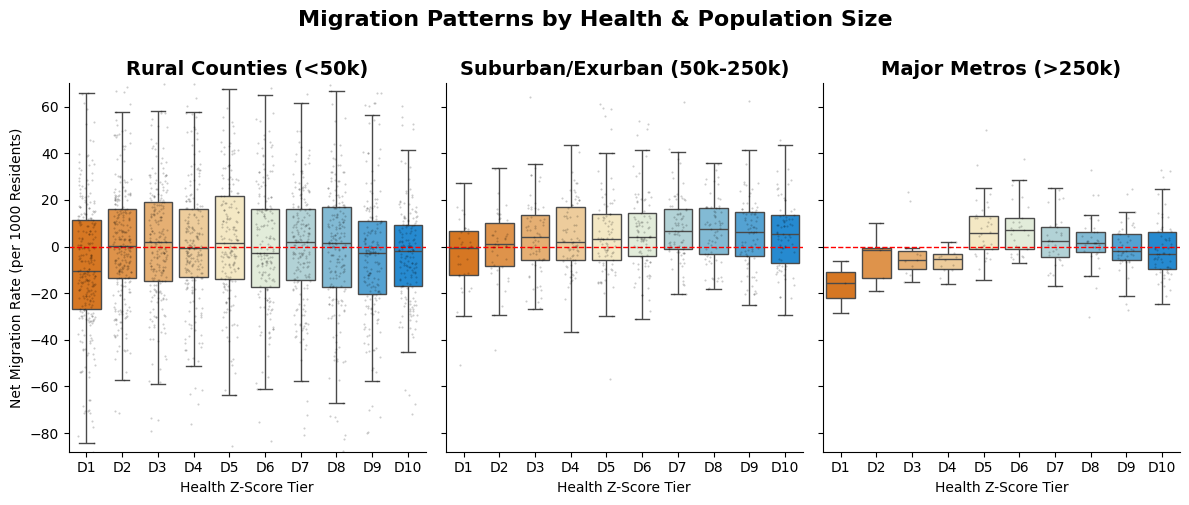

In [19]:
# Create Population Categories
def categorize_pop(pop):
    if pop < 50000:
        return 'Small (<50k)'
    elif pop < 250000:
        return 'Medium (50k-250k)'
    else:
        return 'Large (>250k)'

bin_df['Pop_Size'] = bin_df['Population'].apply(categorize_pop)

# Re-order
order_list = ['Small (<50k)', 'Medium (50k-250k)', 'Large (>250k)']

# Using blue to orange as with previous visuals, added light yellow
orange_hex = "#f47505" 
yellow_hex = "#FDFBD4"
blue_hex   = "#0a8fec" 

# This creates a LIST of 10 colors blending from Orange to Blue
custom_palette = sns.blend_palette([orange_hex,yellow_hex, blue_hex], n_colors=10)

# Visualization: Box Plot + Strip Plot Overlay
g = sns.catplot(
    data=bin_df, 
    x='Health_Decile', 
    y='Net_Migration_Rate', 
    col='Pop_Size', 
    col_order=['Small (<50k)', 'Medium (50k-250k)', 'Large (>250k)'],
    kind='box',              
    showfliers=False,    # Hide outliers from boxplot since we add stripplot
    palette=custom_palette, 
    hue='Health_Decile',   
    legend=False,
    height=5, 
    aspect=0.8
)

# Create a list of the population titles
custom_titles = ["Rural Counties (<50k)", "Suburban/Exurban (50k-250k)", "Major Metros (>250k)"]

# Iterate through the axes and assign the titles
for ax, new_title in zip(g.axes.flat, custom_titles):
    ax.set_title(new_title, fontsize=14, fontweight='bold')
    
# Overlay the raw data points
g.map_dataframe(
    sns.stripplot, 
    x='Health_Decile', 
    y='Net_Migration_Rate', 
    color='black',            
    alpha=0.2,                
    size=1.5,                 
    jitter=0.25               
)

g.set(ylim=(-88, 70))  

# Add reference line
g.map(plt.axhline, y=0, color="red", linestyle="--", linewidth=1)

# Titles
g.fig.suptitle('Migration Patterns by Health & Population Size', y=1, fontsize=16, fontweight='bold')
g.set_axis_labels("Health Z-Score Tier", "Net Migration Rate (per 1000 Residents)")

plt.tight_layout()
plt.show()

In [20]:
bin_df.groupby(['Pop_Size','Health_Decile'], observed=True)['Net_Migration_Rate'].mean().unstack(0).round(2)

Pop_Size,Large (>250k),Medium (50k-250k),Small (<50k)
Health_Decile,,,
D1,-16.88,-4.04,-7.94
D2,-4.90,0.39,1.71
D3,-2.11,4.30,0.07
D4,-6.01,5.45,1.13
D5,7.60,5.90,2.26
D6,7.97,7.55,-2.26
D7,2.79,8.79,-1.36
D8,1.95,6.83,-3.95
D9,-0.83,5.61,-3.52


### Exploratory Bubble Chart
We were mostly curious about seeing this at the state level and did not end up using it for our slide deck. We wanted to take a look at the relationship between Community Conditions and Health Z-scores by aggregating the data to the state level. We created a bubble chart with sns.scatterplot, community condition z-scores on x-axis and health z-scores on y-axis. Calculated rate magnitude (the absolute value of migration) and added it to bubble size so that states with high inflow and outflow were larger, and put net migration rate on color. Blue is pop gain and red is pop loss. The dashed lines at 0 divides the plot into quadrants to show the national averages.

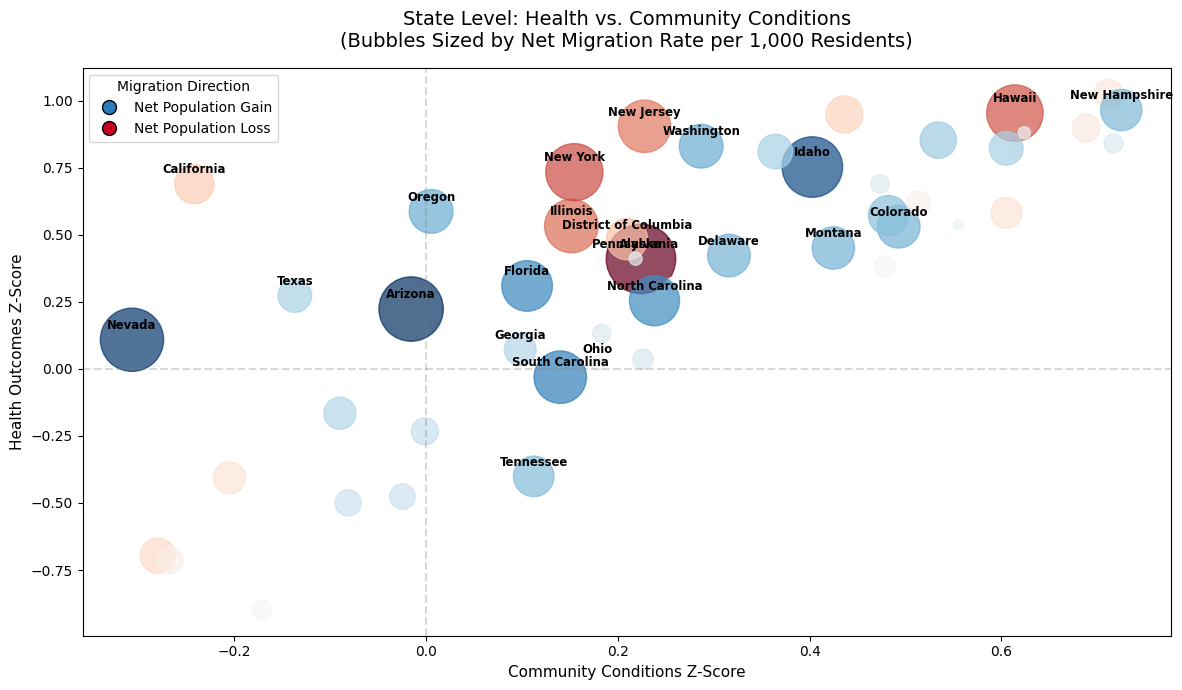

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D # Needed for custom legend

def create_rate_bubble_chart(state_df):
    plt.figure(figsize=(12,7))
    
    # Size: Absolute Value
    state_df['Rate_Magnitude'] = state_df['Net_Migration_Rate'].abs()

    scatter = sns.scatterplot(
        data=state_df, 
        x='Community_Z_Score', 
        y='Health_Z_Score', 
        size='Rate_Magnitude',      
        sizes=(50, 2500), 
        hue='Net_Migration_Rate',   
        palette='RdBu',   
        alpha=0.7,
        edgecolor=None,
        legend=False 
    )

    # Label outliers
    for i in range(len(state_df)):
        rate = state_df['Net_Migration_Rate'].iloc[i]
        # Label if rate is > 5 per 1,000 OR population > 10M
        if abs(rate) > 5.0 or state_df['Population'].iloc[i] > 10000000:  
            plt.text(
                x=state_df['Community_Z_Score'].iloc[i], 
                y=state_df['Health_Z_Score'].iloc[i] + 0.04, 
                s=state_df['State'].iloc[i], 
                horizontalalignment='center', 
                size='small', 
                color='black', 
                weight='bold'
            )

    # Labels
    plt.title("State Level: Health vs. Community Conditions\n(Bubbles Sized by Net Migration Rate per 1,000 Residents)", fontsize=14, pad=15)
    plt.xlabel("Community Conditions Z-Score", fontsize=11)
    plt.ylabel("Health Outcomes Z-Score", fontsize=11)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Net Population Gain',
               markerfacecolor='#2b7bba', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', label='Net Population Loss',
               markerfacecolor='#ca0020', markersize=10, markeredgecolor='k')
    ]
    plt.legend(handles=legend_elements, loc='upper left', title="Migration Direction")

    # Reference lines
    plt.axvline(0, color='gray', linestyle='--', alpha=0.3) # National Avg Conditions
    plt.axhline(0, color='gray', linestyle='--', alpha=0.3) # National Avg Health
    plt.tight_layout()
    plt.show()

create_rate_bubble_chart(state_df)

This shows a positive linear relationship between community conditions and health z-scores.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fba226e9-ff4f-4eec-8dfc-4f877d29c8c6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>